# Setup

In [5]:
# Install and import required libraries
!pip install torch torchvision matplotlib scikit-learn


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


import numpy as np
import matplotlib.pyplot as plt


from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# 2. Load and Preprocess Dataset (Breast Cancer Dataset)

In [6]:
# Load dataset from sklearn
data = load_breast_cancer()
X = data.data
y = data.target


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)


# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)


X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


# Create DataLoader
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 455
Testing samples: 114


### Dataset Split

- 455 samples are used for training the model.
- 114 samples are used for testing the model.
- Most data is used for learning and a smaller part is used for evaluation.


# 3. Define Neural Network Model

In [9]:
class NeuralNet(nn.Module):
  def __init__(self, input_size):
    super(NeuralNet, self).__init__()
    self.model = nn.Sequential(
    nn.Linear(input_size, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid()
    )
  def forward(self, x):
    return self.model(x)

### Neural Network Architecture

- The input layer takes features from the dataset.
- Two hidden layers with 64 and 32 neurons are used.
- ReLU activation is applied in hidden layers to introduce non-linearity.
- A single output neuron with Sigmoid activation is used for binary classification.

# 4. Utility Functions

In [11]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            outputs = model(x)
            loss = criterion(outputs, y)
            total_loss += loss.item()

            preds = (outputs >= 0.5).float()
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total
    avg_loss = total_loss / len(loader)

    return avg_loss, acc


def get_l1_penalty(model):
    l1_norm = 0
    for param in model.parameters():
        l1_norm += torch.sum(torch.abs(param))
    return l1_norm


def get_weight_statistics(model):
    weights = []
    for name, param in model.named_parameters():
        if "weight" in name:
            weights.append(param.detach().cpu().numpy().flatten())

    weights = np.concatenate(weights)

    stats = {
        "mean": np.mean(weights),
        "std": np.std(weights),
        "min": np.min(weights),
        "max": np.max(weights),
        "num_near_zero": np.sum(np.abs(weights) < 1e-3)
    }

    return weights, stats

### Utility Functions

- The evaluate() function calculates loss and accuracy on training or testing data.
- It disables gradient calculation to improve performance during evaluation.
- Predictions are converted into binary values using a threshold of 0.5.

- The get_l1_penalty() function computes the L1 regularization term by summing absolute values of weights.

- The get_weight_statistics() function collects all weight values from the model.
- It calculates mean, standard deviation, minimum, maximum, and near-zero weights.
- Near-zero weights help in analyzing sparsity caused by regularization.


# 5. Training Function (Supports L1, L2, ElasticNet)

In [12]:
def train_model(
    regularization="none",
    l1_lambda=0.0,
    l2_lambda=0.0,
    epochs=50
):

    model = NeuralNet(X_train.shape[1])
    criterion = nn.BCELoss()

    # L2 is handled by weight_decay in optimizer
    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=l2_lambda
    )

    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []
    weight_history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for x, y in train_loader:
            optimizer.zero_grad()

            outputs = model(x)
            loss = criterion(outputs, y)

            # Add L1 penalty if needed
            if regularization in ["l1", "elastic"]:
                l1_penalty = l1_lambda * get_l1_penalty(model)
                loss = loss + l1_penalty

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Evaluation
        train_loss, train_acc = evaluate(model, train_loader, criterion)
        test_loss, test_acc = evaluate(model, test_loader, criterion)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        # Store weights
        weights, _ = get_weight_statistics(model)
        weight_history.append(weights)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Test Loss: {test_loss:.4f} | "
                  f"Test Acc: {test_acc:.4f}")

    return {
        "model": model,
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_accs": train_accs,
        "test_accs": test_accs,
        "weight_history": weight_history
    }


### Model Training Function

- The train_model() function trains the neural network for a given number of epochs.
- It supports No Regularization, L1, L2, and Elastic Net methods.
- Binary Cross Entropy Loss is used for binary classification.
- Adam optimizer is used for updating weights.

- L2 regularization is applied using the weight_decay parameter.
- L1 regularization is added manually to the loss function.
- Elastic Net uses both L1 and L2 penalties together.

- Training and testing loss and accuracy are calculated after each epoch.
- Model weights are stored to analyze changes during training.
- Progress is printed after every 10 epochs.


# 6. Train Models with Different Regularizations

In [13]:
print("\nTraining WITHOUT Regularization")
none_results = train_model(
    regularization="none",
    epochs=60
)

print("\nTraining with L2 Regularization")
l2_results = train_model(
    regularization="l2",
    l2_lambda=0.01,
    epochs=60
)

print("\nTraining with L1 Regularization")
l1_results = train_model(
    regularization="l1",
    l1_lambda=0.0005,
    epochs=60
)

print("\nTraining with Elastic Net")
elastic_results = train_model(
    regularization="elastic",
    l1_lambda=0.0005,
    l2_lambda=0.01,
    epochs=60
)


Training WITHOUT Regularization
Epoch [10/60] | Train Loss: 0.0561 | Test Loss: 0.0556 | Test Acc: 0.9825
Epoch [20/60] | Train Loss: 0.0297 | Test Loss: 0.0592 | Test Acc: 0.9737
Epoch [30/60] | Train Loss: 0.0180 | Test Loss: 0.0693 | Test Acc: 0.9737
Epoch [40/60] | Train Loss: 0.0103 | Test Loss: 0.0755 | Test Acc: 0.9825
Epoch [50/60] | Train Loss: 0.0067 | Test Loss: 0.0820 | Test Acc: 0.9825
Epoch [60/60] | Train Loss: 0.0044 | Test Loss: 0.0879 | Test Acc: 0.9825

Training with L2 Regularization
Epoch [10/60] | Train Loss: 0.0718 | Test Loss: 0.0686 | Test Acc: 0.9912
Epoch [20/60] | Train Loss: 0.0571 | Test Loss: 0.0603 | Test Acc: 0.9912
Epoch [30/60] | Train Loss: 0.0465 | Test Loss: 0.0577 | Test Acc: 0.9912
Epoch [40/60] | Train Loss: 0.0460 | Test Loss: 0.0579 | Test Acc: 0.9912
Epoch [50/60] | Train Loss: 0.0391 | Test Loss: 0.0600 | Test Acc: 0.9825
Epoch [60/60] | Train Loss: 0.0397 | Test Loss: 0.0587 | Test Acc: 0.9912

Training with L1 Regularization
Epoch [10/60]

### Training Performance Interpretation

#### Without Regularization
- Training loss continuously decreases, showing that the model fits the training data very well.
- Test loss gradually increases after some epochs, indicating overfitting.
- The model starts memorizing training data instead of generalizing.
- High accuracy is achieved, but stability on test data is lower.

#### With L2 Regularization
- Training loss decreases slowly compared to no regularization.
- Test loss remains stable throughout training.
- L2 regularization controls weight growth and prevents overfitting.
- Test accuracy remains high and consistent.
- The model shows better generalization than without regularization.

#### With L1 Regularization
- Training loss decreases but shows some fluctuations.
- Test loss remains relatively low and stable.
- L1 regularization forces some weights towards zero.
- This leads to a simpler and more sparse model.
- Slight drop in accuracy indicates feature selection behavior.

#### With Elastic Net Regularization
- Training loss decreases gradually and remains stable.
- Test loss reduces steadily without sharp increase.
- Elastic Net combines the benefits of L1 and L2 regularization.
- It controls weight size and also creates sparsity.
- The model shows balanced performance and strong generalization.

# 7. Plot Training & Testing Loss

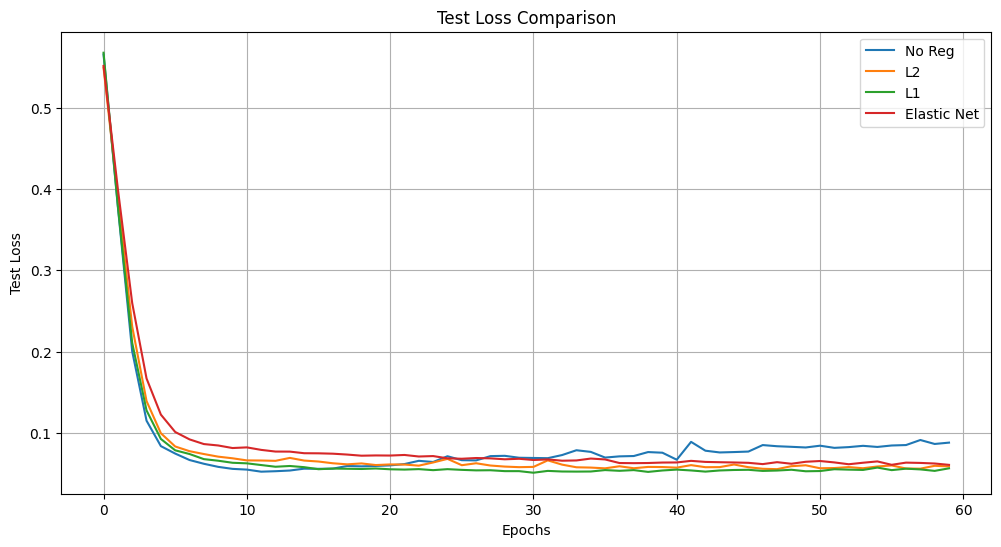

In [14]:
plt.figure(figsize=(12, 6))

plt.plot(none_results["test_losses"], label="No Reg")
plt.plot(l2_results["test_losses"], label="L2")
plt.plot(l1_results["test_losses"], label="L1")
plt.plot(elastic_results["test_losses"], label="Elastic Net")

plt.xlabel("Epochs")
plt.ylabel("Test Loss")
plt.title("Test Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

### Test Loss Comparison Interpretation

- All models show a rapid decrease in test loss during initial epochs.
- This indicates that the models learn important patterns quickly.

- The model without regularization shows an increase in test loss after some epochs.
- This indicates overfitting on training data.

- The L2 regularized model maintains a lower and more stable test loss.
- This shows better generalization to unseen data.

- The L1 regularized model also keeps test loss relatively low.
- Some fluctuations appear due to weight sparsity.

- The Elastic Net model shows smooth and stable loss reduction.
- It balances the behavior of L1 and L2 regularization.

- Regularized models perform better than the unregularized model in controlling overfitting.

# 8. Plot Accuracy Comparison

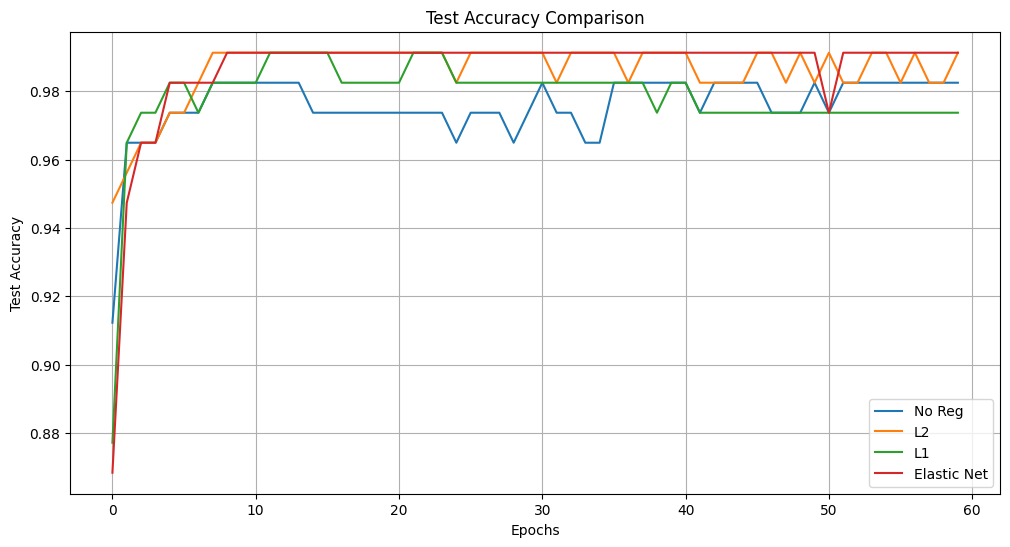

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(none_results["test_accs"], label="No Reg")
plt.plot(l2_results["test_accs"], label="L2")
plt.plot(l1_results["test_accs"], label="L1")
plt.plot(elastic_results["test_accs"], label="Elastic Net")

plt.xlabel("Epochs")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()

### Test Accuracy Comparison Interpretation

- All models reach high accuracy within a few epochs.
- The model without regularization shows more fluctuations.
- L2 and Elastic Net maintain more stable accuracy.
- Regularization improves consistency in model performance.

# 9. Weight Distribution Analysis

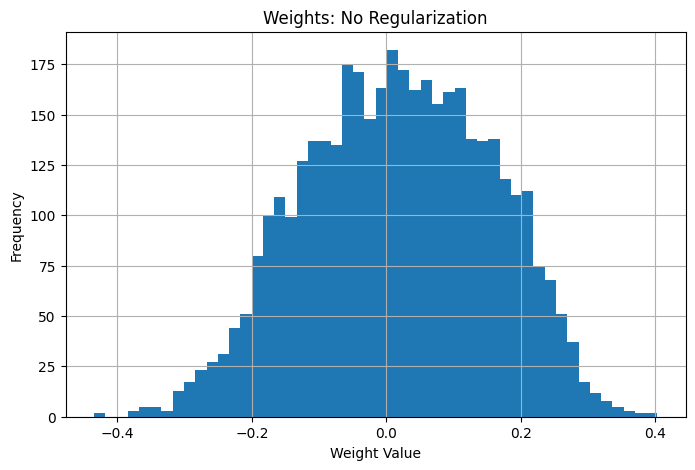

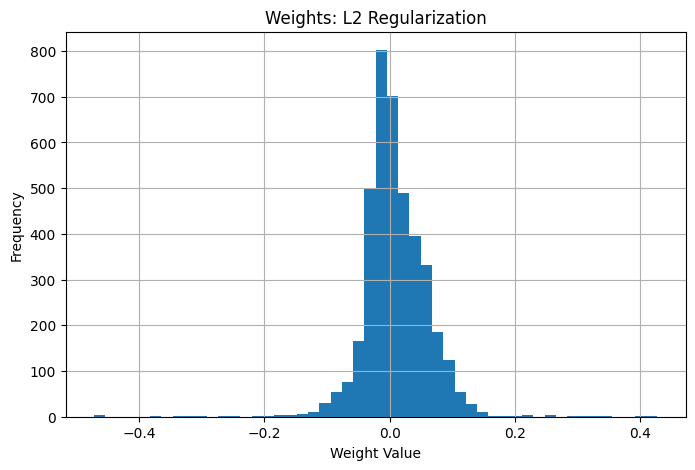

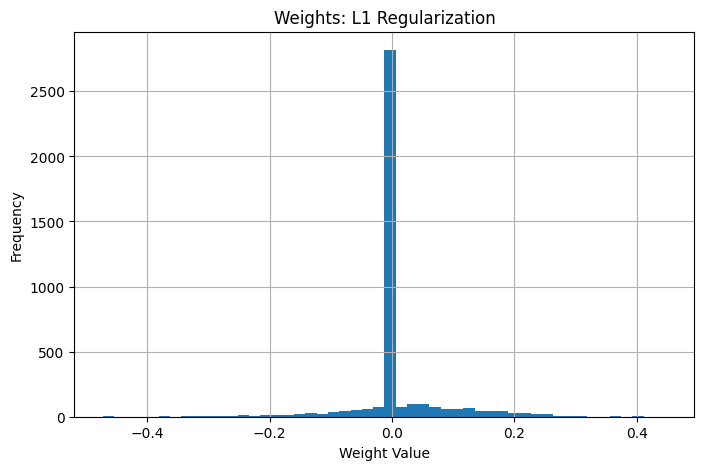

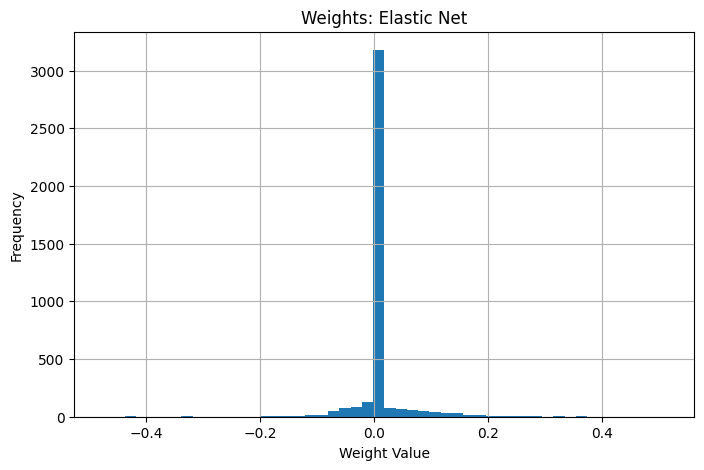

In [16]:
def plot_weight_distribution(results, title):
    final_weights = results["weight_history"][-1]

    plt.figure(figsize=(8, 5))
    plt.hist(final_weights, bins=50)
    plt.title(title)
    plt.xlabel("Weight Value")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()


plot_weight_distribution(none_results, "Weights: No Regularization")
plot_weight_distribution(l2_results, "Weights: L2 Regularization")
plot_weight_distribution(l1_results, "Weights: L1 Regularization")
plot_weight_distribution(elastic_results, "Weights: Elastic Net")

### Weight Distribution Interpretation

- Without regularization, weights are widely spread, indicating larger and uncontrolled values.
- L2 regularization concentrates weights near zero, reducing their magnitude.
- L1 regularization forces many weights to become exactly or nearly zero, creating sparsity.
- Elastic Net shows both controlled weight size and sparsity by combining L1 and L2 effects.

# 10. Weight Sparsity Analysis

In [17]:
def print_weight_stats(results, name):
    model = results["model"]
    weights, stats = get_weight_statistics(model)

    print(f"\n{name} Weight Statistics")
    print("---------------------------")
    print("Mean           :", round(stats["mean"], 6))
    print("Std Dev        :", round(stats["std"], 6))
    print("Min            :", round(stats["min"], 6))
    print("Max            :", round(stats["max"], 6))
    print("Near-Zero Count:", stats["num_near_zero"])
    print("Total Weights  :", len(weights))


print_weight_stats(none_results, "No Regularization")
print_weight_stats(l2_results, "L2 Regularization")
print_weight_stats(l1_results, "L1 Regularization")
print_weight_stats(elastic_results, "Elastic Net")


No Regularization Weight Statistics
---------------------------
Mean           : 0.017396
Std Dev        : 0.138573
Min            : -0.435066
Max            : 0.403476
Near-Zero Count: 18
Total Weights  : 4000

L2 Regularization Weight Statistics
---------------------------
Mean           : 0.008976
Std Dev        : 0.052173
Min            : -0.472418
Max            : 0.427316
Near-Zero Count: 168
Total Weights  : 4000

L1 Regularization Weight Statistics
---------------------------
Mean           : 0.01005
Std Dev        : 0.070995
Min            : -0.473066
Max            : 0.447996
Near-Zero Count: 2427
Total Weights  : 4000

Elastic Net Weight Statistics
---------------------------
Mean           : 0.005212
Std Dev        : 0.047988
Min            : -0.476684
Max            : 0.512758
Near-Zero Count: 3040
Total Weights  : 4000


### Weight Statistics Interpretation

- Without regularization, very few weights are near zero, showing less control over model complexity.
- L2 regularization reduces the standard deviation, indicating smaller and more stable weights.
- L1 regularization produces a large number of near-zero weights, showing strong sparsity.
- Elastic Net produces the highest sparsity while keeping weights well controlled.
- Regularization helps in simplifying the model by reducing unnecessary weights.

# 11. Weight Evolution Over Epochs

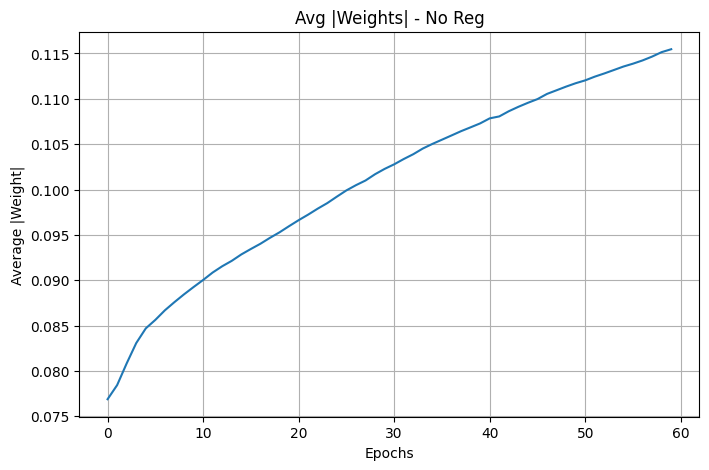

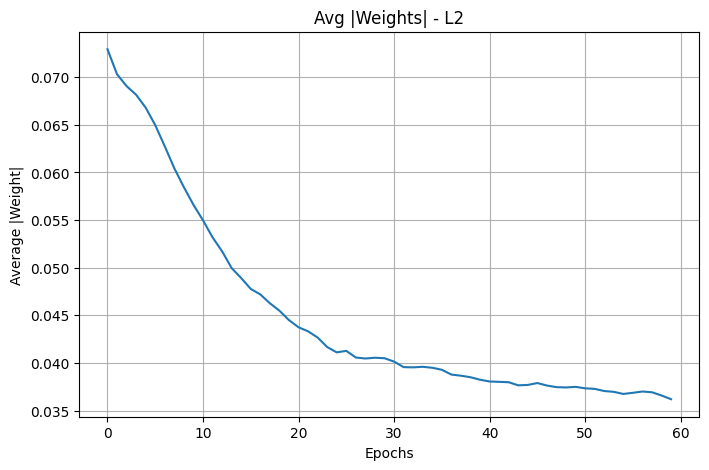

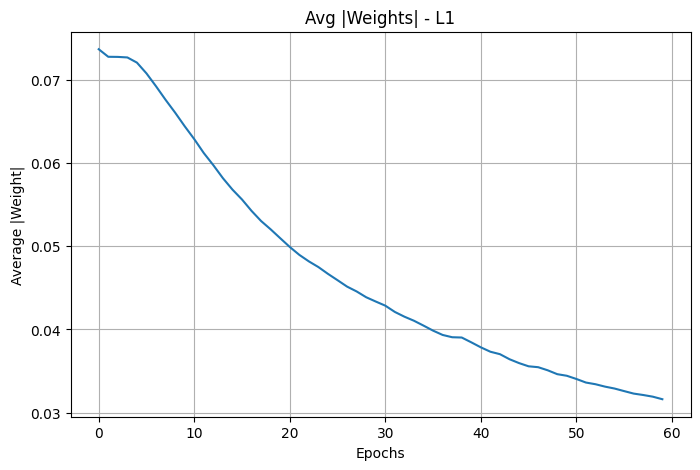

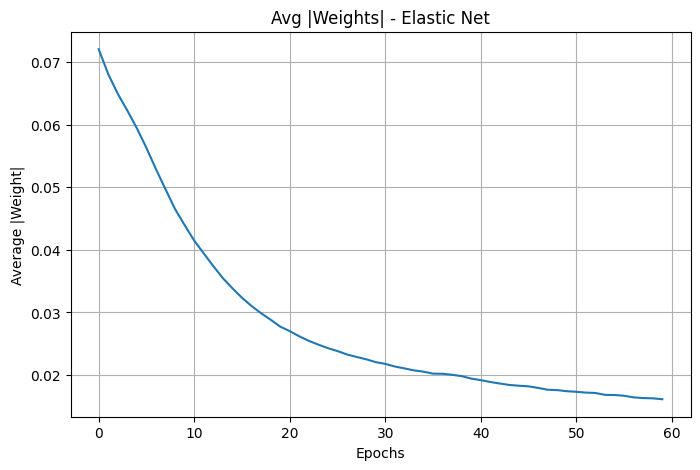

In [18]:
def plot_weight_evolution(results, title):
    history = results["weight_history"]

    avg_abs_weights = [np.mean(np.abs(w)) for w in history]

    plt.figure(figsize=(8, 5))
    plt.plot(avg_abs_weights)
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Average |Weight|")
    plt.grid(True)
    plt.show()


plot_weight_evolution(none_results, "Avg |Weights| - No Reg")
plot_weight_evolution(l2_results, "Avg |Weights| - L2")
plot_weight_evolution(l1_results, "Avg |Weights| - L1")
plot_weight_evolution(elastic_results, "Avg |Weights| - Elastic Net")


### Weight Evolution Interpretation

- Without regularization, average weight values increase continuously, indicating uncontrolled growth.
- L2 regularization gradually reduces weight magnitude and keeps them stable.
- L1 regularization strongly reduces weights, pushing many towards zero.
- Elastic Net shows the strongest control over weight values by combining L1 and L2 effects.
- Regularization helps in preventing overfitting by limiting weight growth.

# 12. Final Performance Summary

In [19]:
def print_final_results(name, results):
    print(f"\n{name} Final Results")
    print("----------------------")
    print("Final Train Accuracy:", round(results["train_accs"][-1], 4))
    print("Final Test Accuracy :", round(results["test_accs"][-1], 4))
    print("Final Test Loss     :", round(results["test_losses"][-1], 4))


print_final_results("No Regularization", none_results)
print_final_results("L2 Regularization", l2_results)
print_final_results("L1 Regularization", l1_results)
print_final_results("Elastic Net", elastic_results)


No Regularization Final Results
----------------------
Final Train Accuracy: 0.9978
Final Test Accuracy : 0.9825
Final Test Loss     : 0.0879

L2 Regularization Final Results
----------------------
Final Train Accuracy: 0.9912
Final Test Accuracy : 0.9912
Final Test Loss     : 0.0587

L1 Regularization Final Results
----------------------
Final Train Accuracy: 0.9934
Final Test Accuracy : 0.9737
Final Test Loss     : 0.0563

Elastic Net Final Results
----------------------
Final Train Accuracy: 0.989
Final Test Accuracy : 0.9912
Final Test Loss     : 0.0606


### Final Performance Interpretation

- Without regularization, training accuracy is very high, indicating possible overfitting.
- L2 regularization achieves balanced training and testing accuracy with low test loss.
- L1 regularization reduces model complexity but slightly lowers test accuracy.
- Elastic Net provides stable accuracy and good generalization.
- L2 and Elastic Net show the best overall performance on unseen data.